# Exploratory Data Analysis — Xente Credit Risk Dataset
**10 Academy KAIM 9 | Week 4 | Task 2**

**Objective:** Explore the dataset to uncover patterns, identify data quality issues, and form hypotheses to guide feature engineering.

---

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# ── Load data ────────────────────────────────────────────────
# Place the Xente CSV in data/raw/ before running
DATA_PATH = '../data/raw/data.csv'
df = pd.read_csv(DATA_PATH)

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset loaded: 95,662 rows × 16 columns


---
## 1. Overview of the Data

In [2]:
print('=' * 55)
print('SHAPE')
print('=' * 55)
print(f'Rows   : {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')

SHAPE
Rows   : 95,662
Columns: 16


In [3]:
print('\nFIRST 5 ROWS')
df.head()


FIRST 5 ROWS


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [4]:
print('\nCOLUMN DATA TYPES')
print(df.dtypes.to_string())


COLUMN DATA TYPES
TransactionId            object
BatchId                  object
AccountId                object
SubscriptionId           object
CustomerId               object
CurrencyCode             object
CountryCode               int64
ProviderId               object
ProductId                object
ProductCategory          object
ChannelId                object
Amount                  float64
Value                     int64
TransactionStartTime     object
PricingStrategy           int64
FraudResult               int64


In [5]:
# Separate column types for later use
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f'Numerical columns  ({len(num_cols)}): {num_cols}')
print(f'Categorical columns({len(cat_cols)}): {cat_cols}')

Numerical columns  (5): ['CountryCode', 'Amount', 'Value', 'PricingStrategy', 'FraudResult']
Categorical columns(11): ['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'TransactionStartTime']


In [6]:
# Parse timestamp
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'], utc=True)
print('Timestamp range:')
print(f'  Earliest : {df["TransactionStartTime"].min()}')
print(f'  Latest   : {df["TransactionStartTime"].max()}')
print(f'  Span     : {(df["TransactionStartTime"].max() - df["TransactionStartTime"].min()).days} days')

Timestamp range:
  Earliest : 2018-11-15 02:18:49+00:00
  Latest   : 2019-02-13 10:01:28+00:00
  Span     : 90 days


In [7]:
# Unique counts for ID columns
id_cols = ['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId']
print('UNIQUE VALUE COUNTS FOR KEY IDENTIFIERS')
for col in id_cols:
    print(f'  {col:<20}: {df[col].nunique():,}')

UNIQUE VALUE COUNTS FOR KEY IDENTIFIERS
  TransactionId       : 95,662
  BatchId             : 94,809
  AccountId           : 3,633
  SubscriptionId      : 3,627
  CustomerId          : 3,742


---
## 2. Summary Statistics

In [8]:
print('NUMERICAL SUMMARY STATISTICS')
df[num_cols].describe().T.round(2)

NUMERICAL SUMMARY STATISTICS


,count,mean,std,min,25%,50%,75%,max
CountryCode,95662.0,256.00,0.00,256.0,256.0,256.0,256.0,256.0
Amount,95662.0,6717.85,123306.80,-1000000.0,-50.0,1000.0,2800.0,9880000.0
Value,95662.0,9900.58,123122.09,2.0,275.0,1000.0,5000.0,9880000.0
PricingStrategy,95662.0,2.26,0.73,0.0,2.0,2.0,2.0,4.0
FraudResult,95662.0,0.00,0.04,0.0,0.0,0.0,0.0,1.0


In [9]:
# Extended stats: skewness and kurtosis
stats = pd.DataFrame({
    'mean'    : df[num_cols].mean(),
    'median'  : df[num_cols].median(),
    'std'     : df[num_cols].std(),
    'skewness': df[num_cols].skew(),
    'kurtosis': df[num_cols].kurt(),
    'min'     : df[num_cols].min(),
    'max'     : df[num_cols].max(),
}).round(3)

print('EXTENDED STATISTICS (including skewness & kurtosis)')
display(stats)

EXTENDED STATISTICS (including skewness & kurtosis)


,mean,median,std,skewness,kurtosis,min,max
CountryCode,256.000,256.0,0.000,0.000,0.000,256.0,256.0
Amount,6717.846,1000.0,123306.797,51.098,3363.128,-1000000.0,9880000.0
Value,9900.584,1000.0,123122.088,51.291,3378.069,2.0,9880000.0
PricingStrategy,2.256,2.0,0.733,1.659,2.088,0.0,4.0
FraudResult,0.002,0.0,0.045,22.196,490.686,0.0,1.0


In [10]:
# Fraud rate
fraud_rate = df['FraudResult'].mean() * 100
print(f'Fraud rate (FraudResult=1): {fraud_rate:.4f}%')
print(df['FraudResult'].value_counts())

Fraud rate (FraudResult=1): 0.2018%
FraudResult
0    95469
1      193
Name: count, dtype: int64


---
## 3. Distribution of Numerical Features

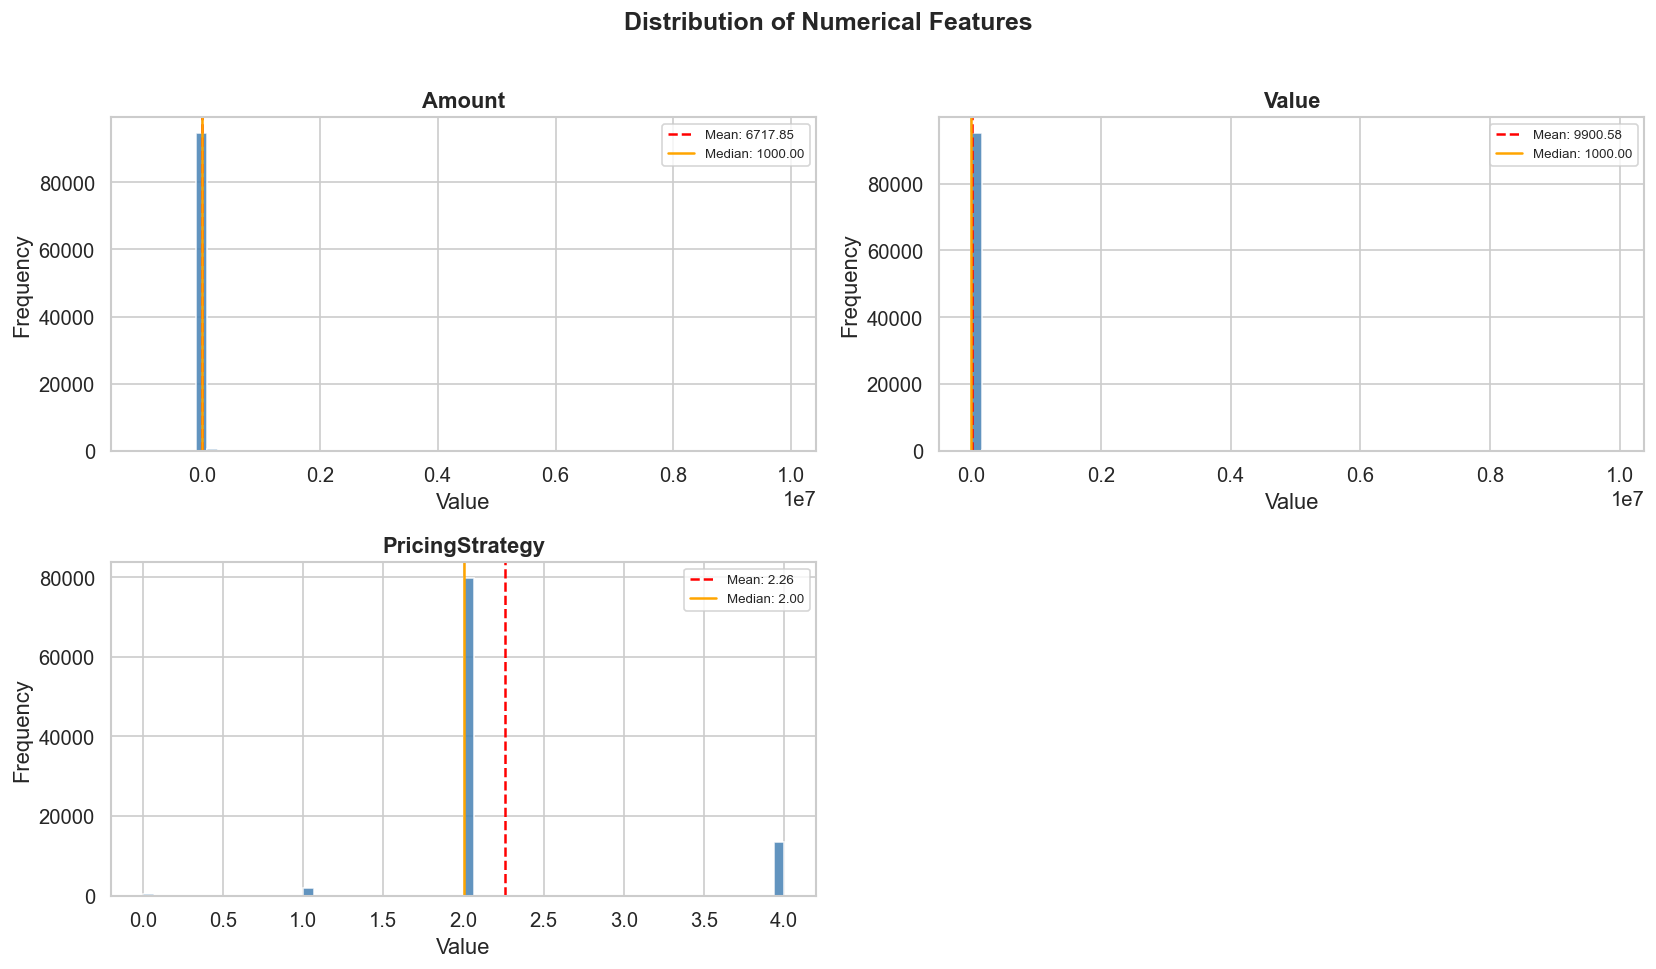

In [11]:
plot_num = [c for c in num_cols if c not in ['FraudResult', 'CountryCode']]
n = len(plot_num)
ncols = 2
nrows = (n + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(plot_num):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.2f}')
    ax.axvline(data.median(), color='orange', linestyle='-',  linewidth=1.5, label=f'Median: {data.median():.2f}')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

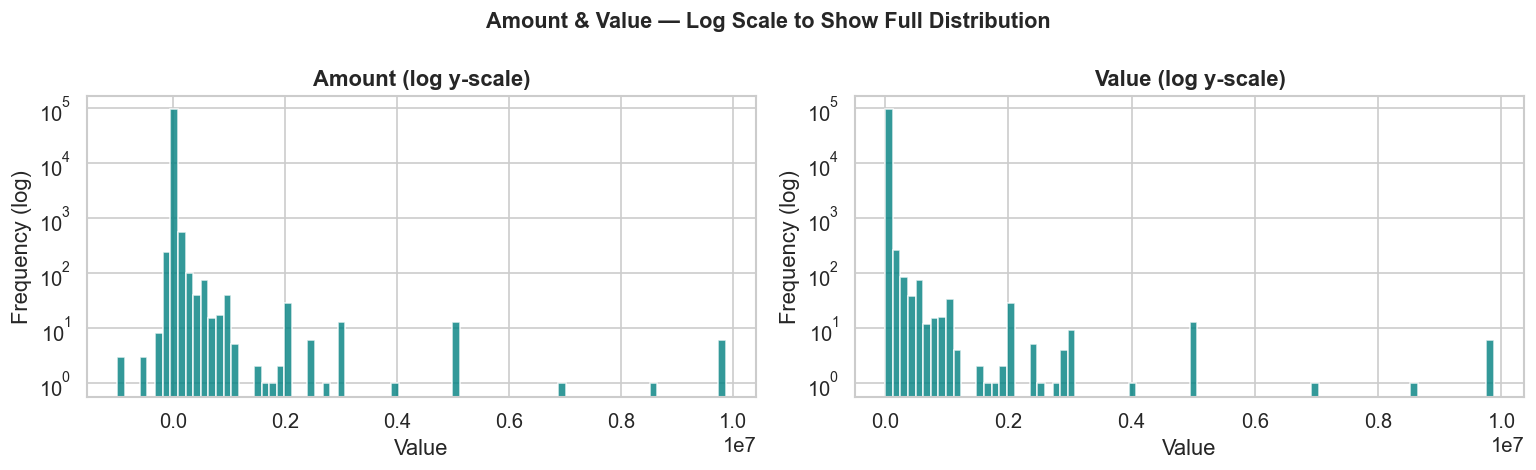

In [12]:
# Log-scale view of Amount and Value (heavily skewed)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col in zip(axes, ['Amount', 'Value']):
    data = df[col].dropna()
    ax.hist(data, bins=80, color='teal', edgecolor='white', alpha=0.8)
    ax.set_yscale('log')
    ax.set_title(f'{col} (log y-scale)', fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency (log)')

plt.suptitle('Amount & Value — Log Scale to Show Full Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

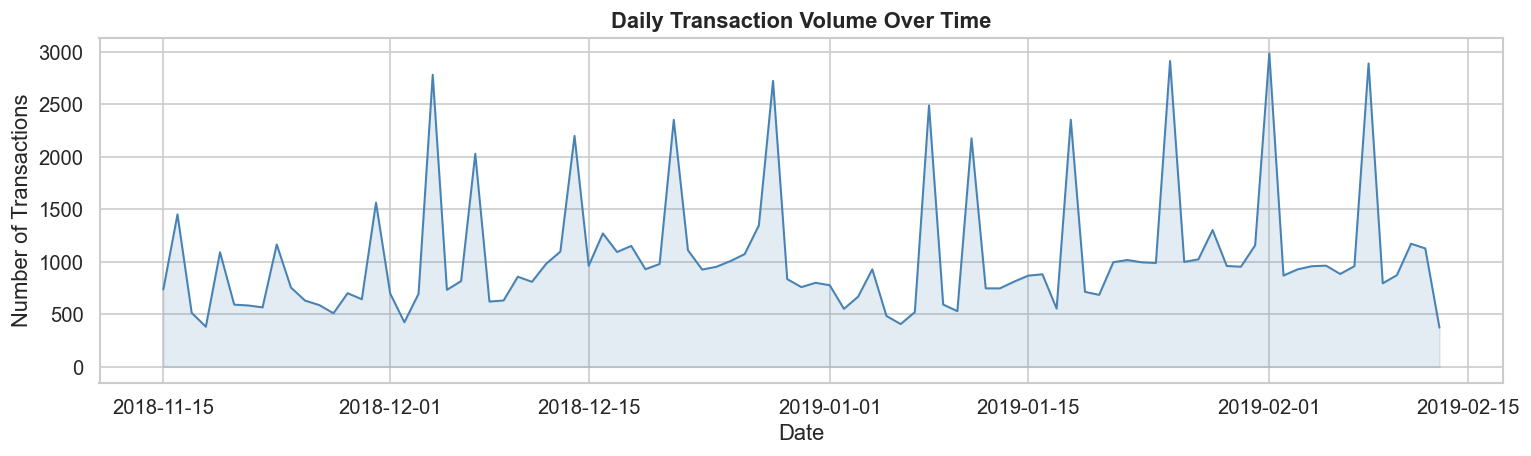

In [13]:
# Transaction volume over time
df['date'] = df['TransactionStartTime'].dt.date
daily = df.groupby('date').size().reset_index(name='count')
daily['date'] = pd.to_datetime(daily['date'])

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily['date'], daily['count'], color='steelblue', linewidth=1.2)
ax.fill_between(daily['date'], daily['count'], alpha=0.15, color='steelblue')
ax.set_title('Daily Transaction Volume Over Time', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

---
## 4. Distribution of Categorical Features

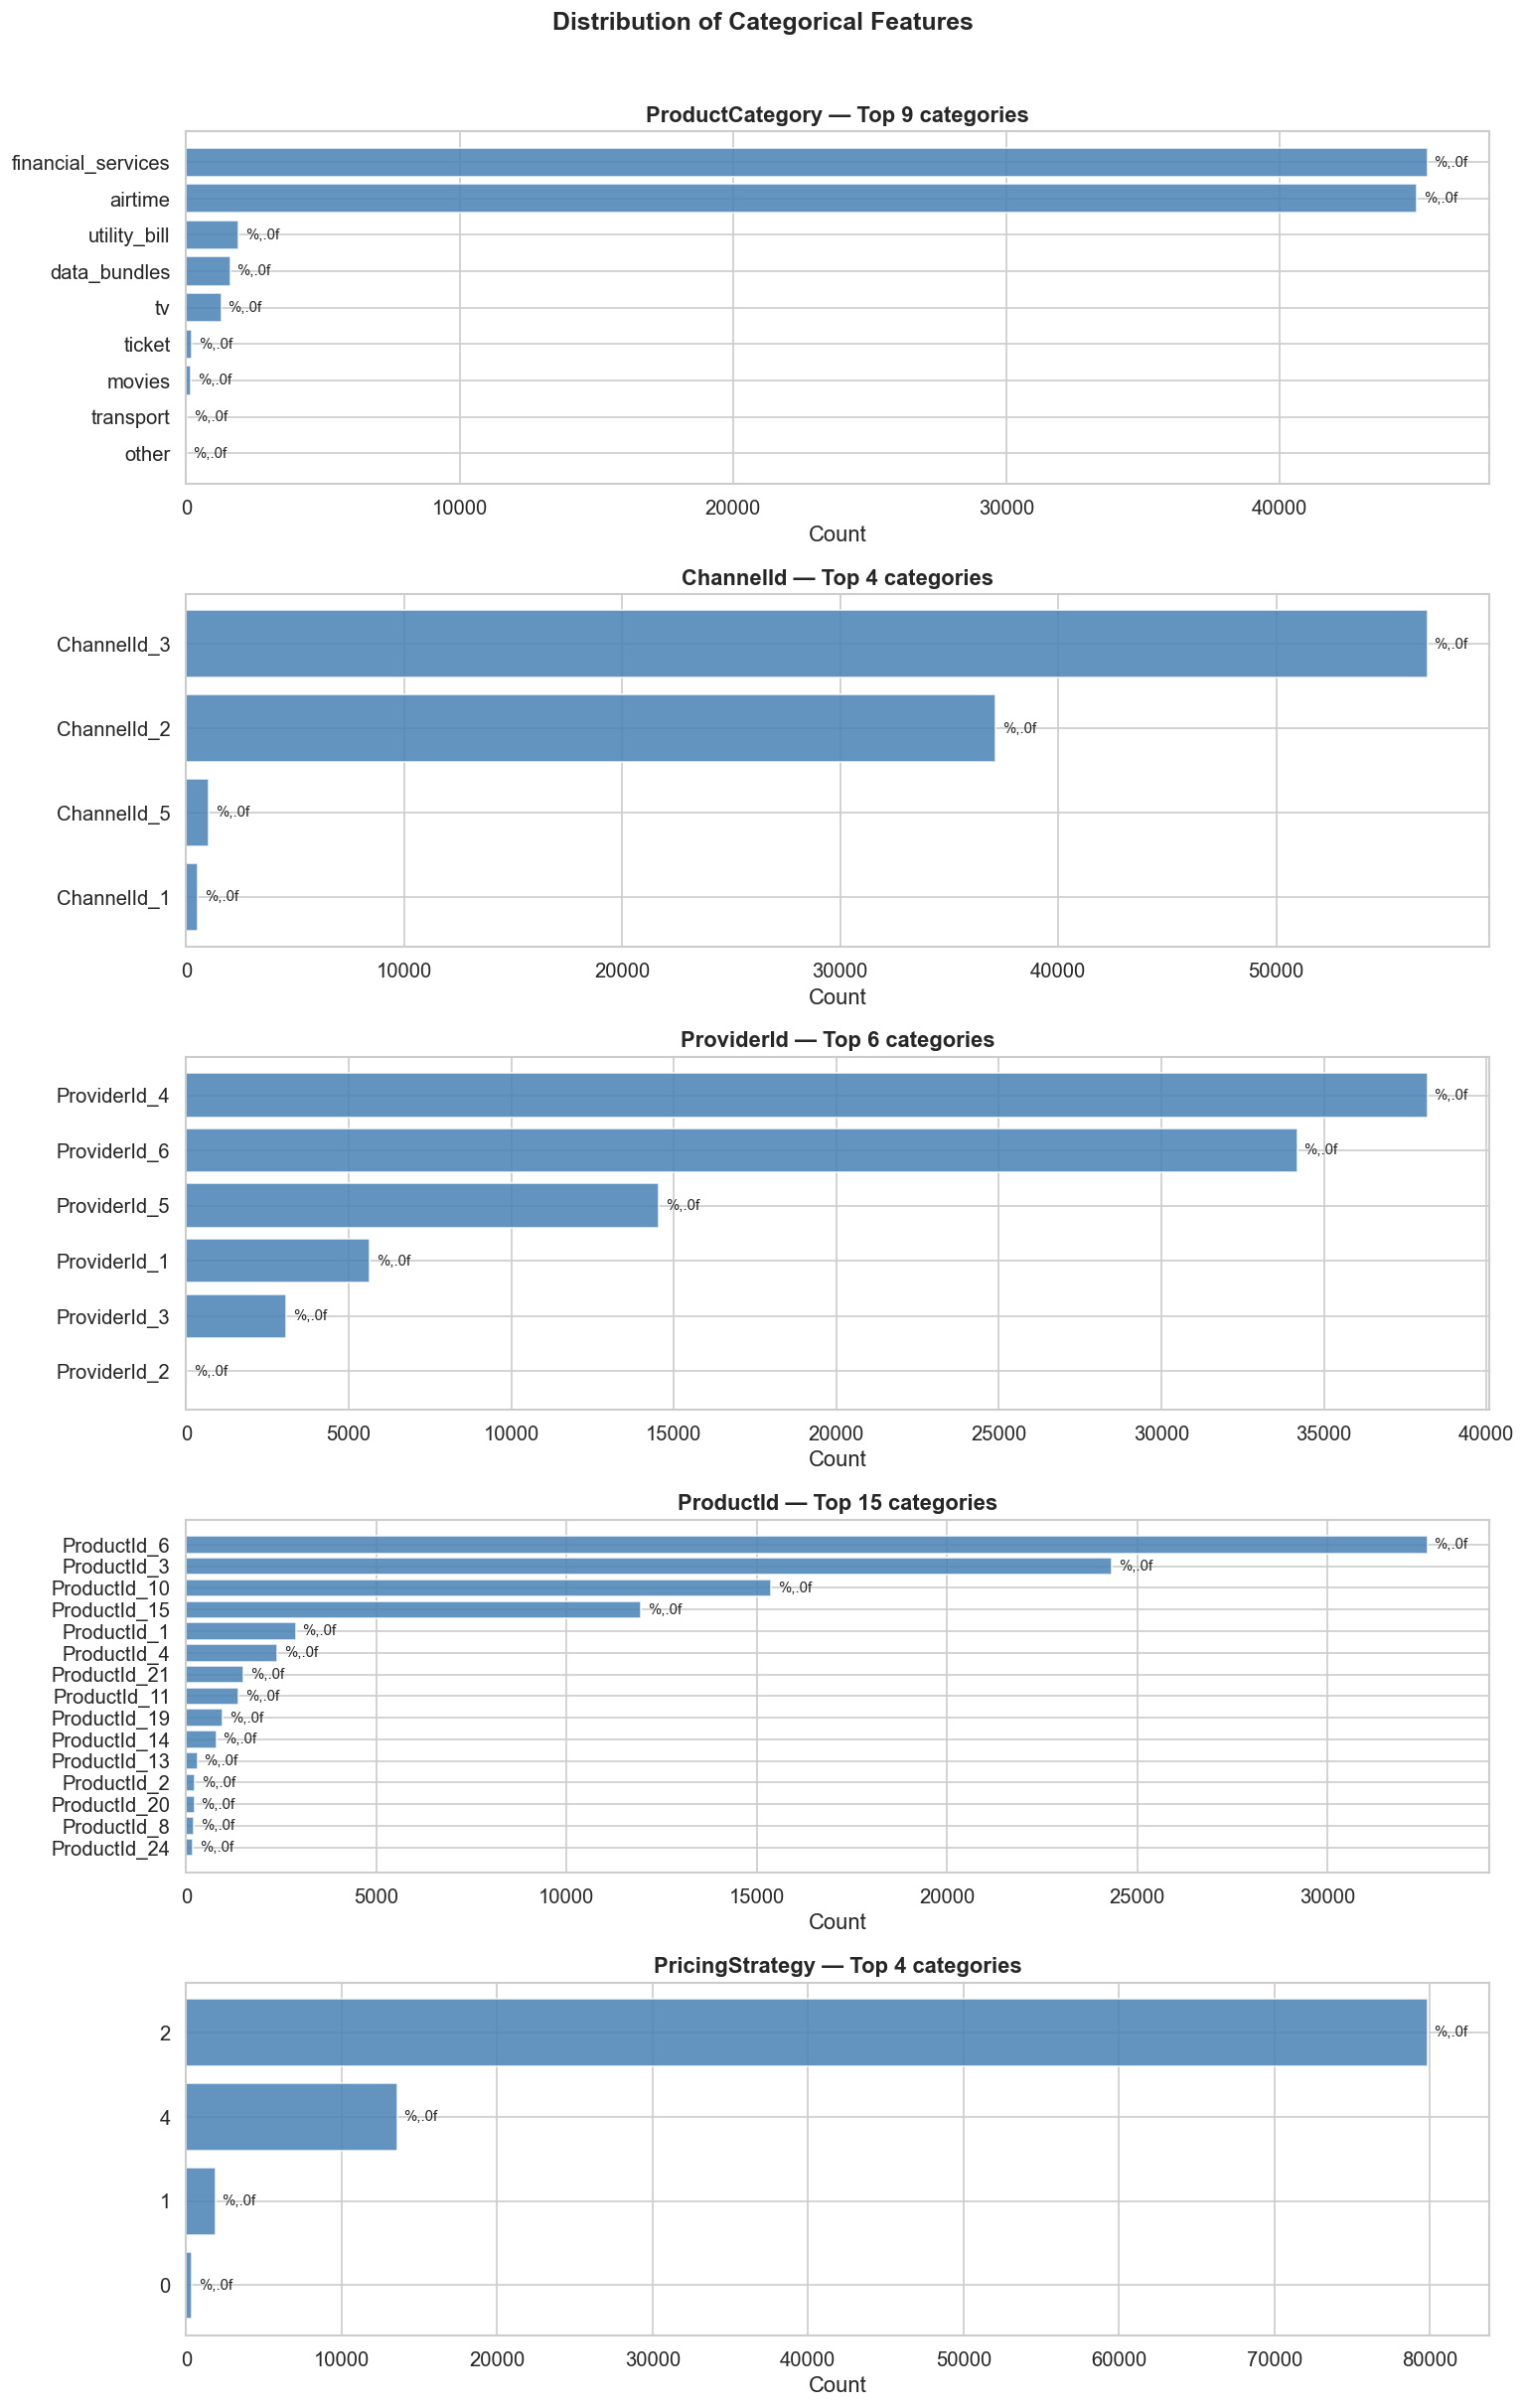

In [14]:
# Categorical columns to plot (exclude pure IDs)
plot_cat = ['ProductCategory', 'ChannelId', 'ProviderId', 'ProductId', 'PricingStrategy']
plot_cat = [c for c in plot_cat if c in df.columns]

fig, axes = plt.subplots(len(plot_cat), 1, figsize=(13, len(plot_cat) * 4))
if len(plot_cat) == 1:
    axes = [axes]

for ax, col in zip(axes, plot_cat):
    counts = df[col].value_counts().head(15)
    bars = ax.barh(counts.index.astype(str), counts.values, color='steelblue', alpha=0.85)
    ax.bar_label(bars, fmt='%,.0f', padding=4, fontsize=9)
    ax.set_title(f'{col} — Top {len(counts)} categories', fontweight='bold')
    ax.set_xlabel('Count')
    ax.invert_yaxis()

plt.suptitle('Distribution of Categorical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

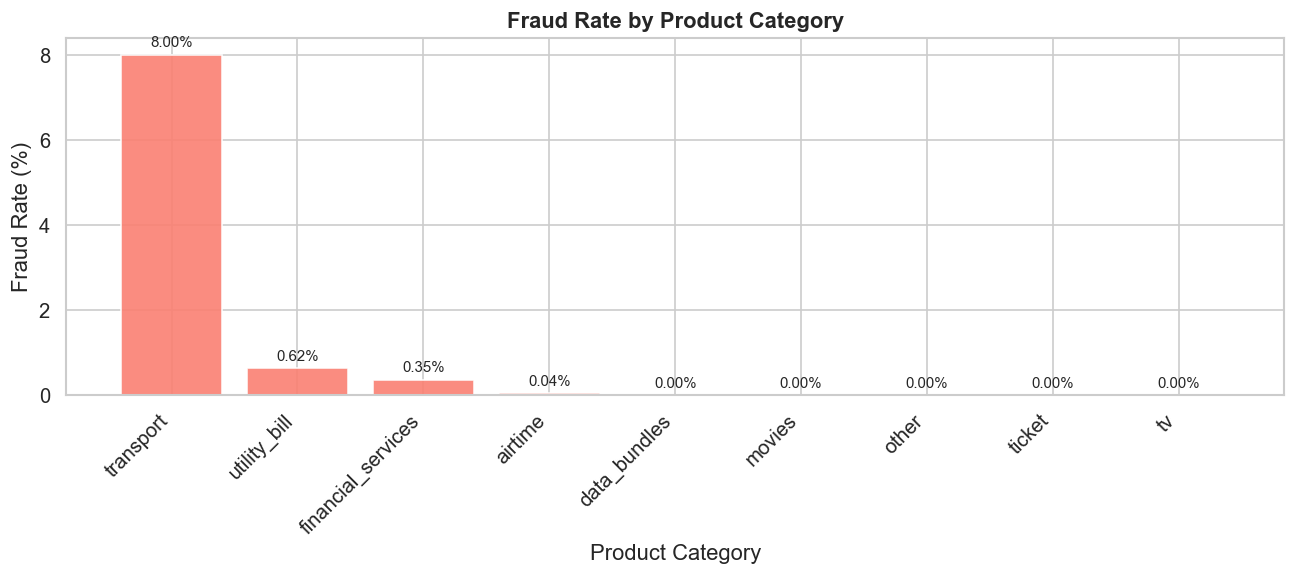

In [15]:
# Fraud rate per ProductCategory
fraud_by_cat = (
    df.groupby('ProductCategory')['FraudResult']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'fraud_count', 'count': 'total'})
)
fraud_by_cat['fraud_rate'] = fraud_by_cat['fraud_count'] / fraud_by_cat['total'] * 100
fraud_by_cat = fraud_by_cat.sort_values('fraud_rate', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(fraud_by_cat.index, fraud_by_cat['fraud_rate'],
              color='salmon', edgecolor='white', alpha=0.9)
ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=9)
ax.set_title('Fraud Rate by Product Category', fontweight='bold')
ax.set_xlabel('Product Category')
ax.set_ylabel('Fraud Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

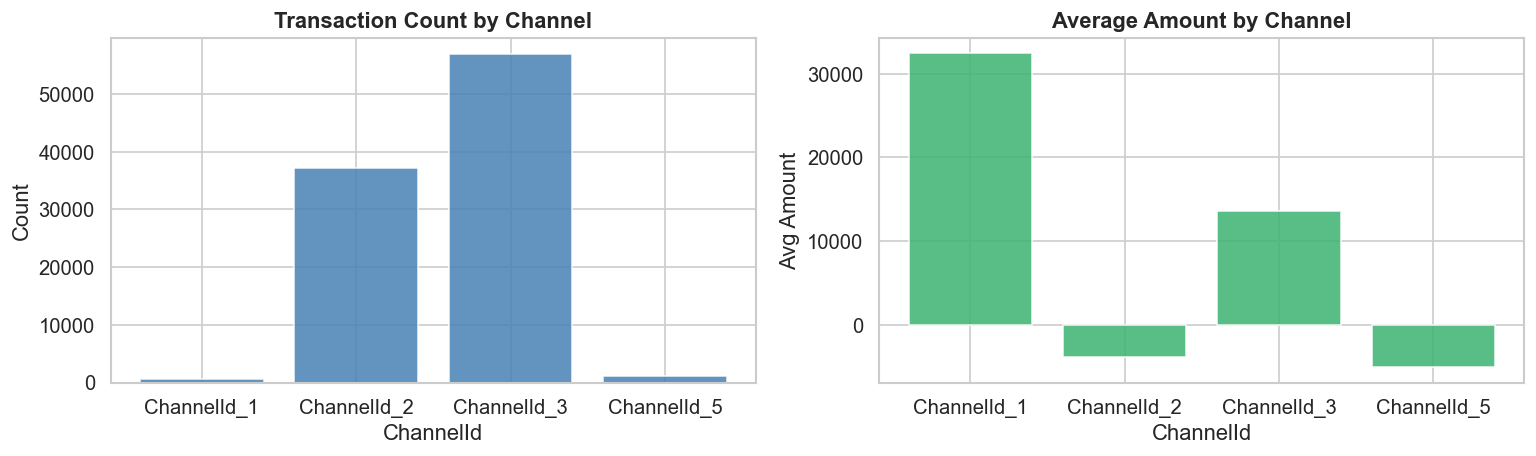

In [16]:
# Transaction count and average amount by channel
channel_stats = df.groupby('ChannelId').agg(
    transaction_count=('TransactionId', 'count'),
    avg_amount=('Amount', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(channel_stats['ChannelId'].astype(str),
            channel_stats['transaction_count'],
            color='steelblue', alpha=0.85)
axes[0].set_title('Transaction Count by Channel', fontweight='bold')
axes[0].set_xlabel('ChannelId')
axes[0].set_ylabel('Count')

axes[1].bar(channel_stats['ChannelId'].astype(str),
            channel_stats['avg_amount'],
            color='mediumseagreen', alpha=0.85)
axes[1].set_title('Average Amount by Channel', fontweight='bold')
axes[1].set_xlabel('ChannelId')
axes[1].set_ylabel('Avg Amount')

plt.tight_layout()
plt.show()

---
## 5. Correlation Analysis

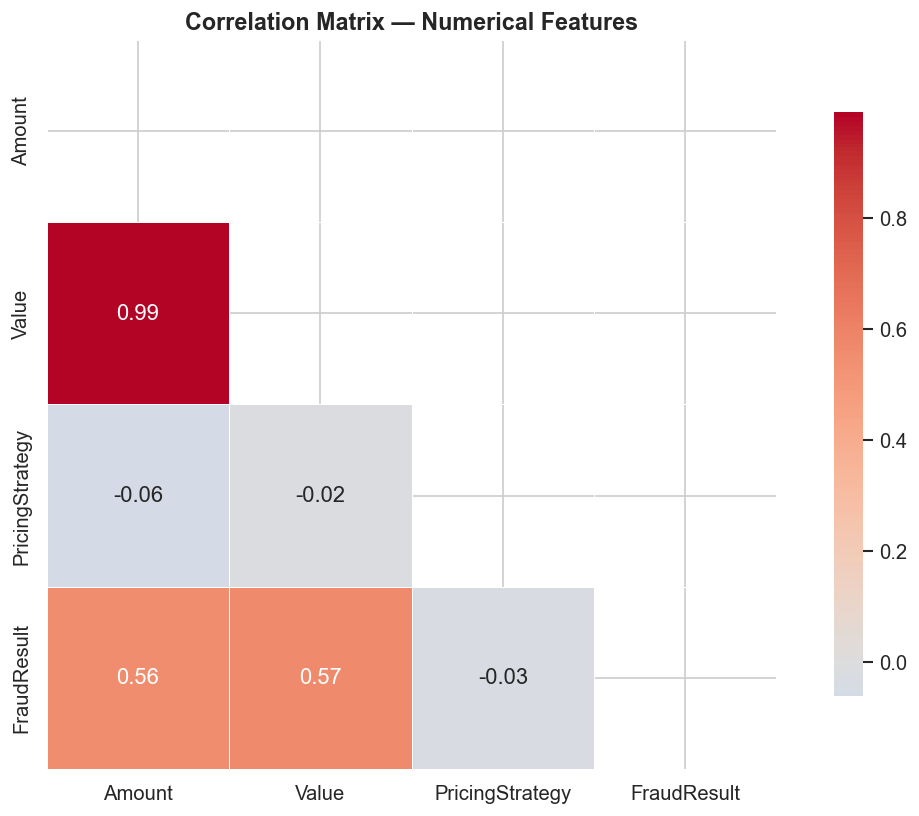

In [17]:
corr_cols = [c for c in num_cols if c not in ['CountryCode']]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Correlation Matrix — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

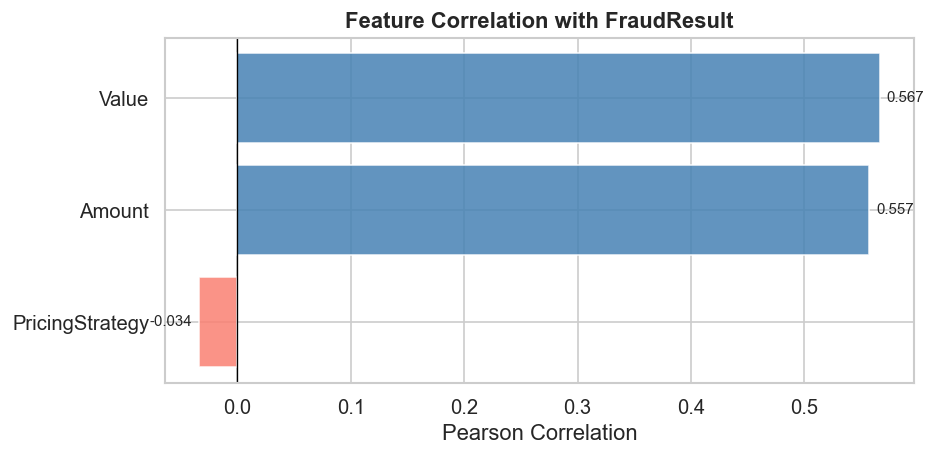

In [18]:
# Correlation with FraudResult specifically
fraud_corr = df[corr_cols].corr()['FraudResult'].drop('FraudResult').sort_values()

colors = ['salmon' if v < 0 else 'steelblue' for v in fraud_corr]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(fraud_corr.index, fraud_corr.values, color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
ax.set_title('Feature Correlation with FraudResult', fontweight='bold')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

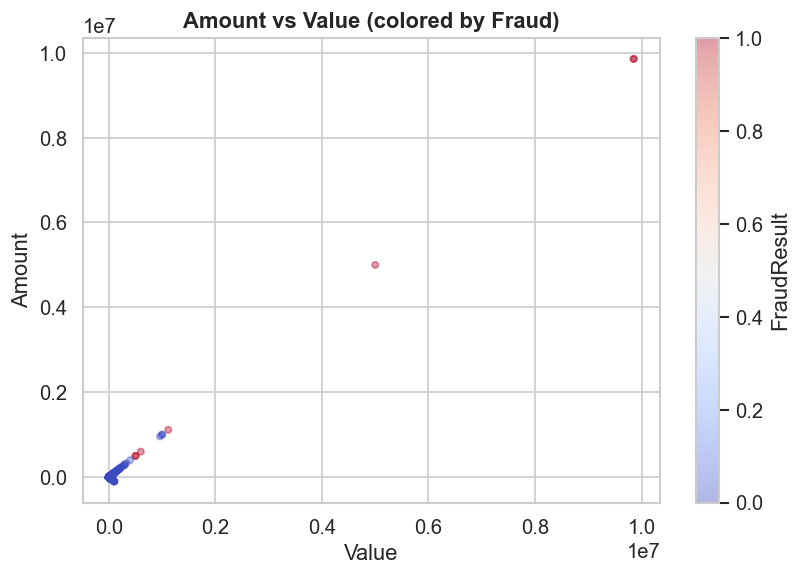

In [19]:
# Amount vs Value scatter
sample = df.sample(min(5000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    sample['Value'], sample['Amount'],
    c=sample['FraudResult'], cmap='coolwarm',
    alpha=0.4, s=15
)
plt.colorbar(scatter, ax=ax, label='FraudResult')
ax.set_title('Amount vs Value (colored by Fraud)', fontweight='bold')
ax.set_xlabel('Value')
ax.set_ylabel('Amount')
plt.tight_layout()
plt.show()

---
## 6. Identifying Missing Values

In [20]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct'  : df.isnull().mean() * 100
}).sort_values('missing_pct', ascending=False)

print('MISSING VALUE SUMMARY')
print(missing[missing['missing_count'] > 0].to_string() if missing['missing_count'].sum() > 0
      else '✅  No missing values found in any column.')
print(f'\nTotal cells : {df.size:,}')
print(f'Missing cells: {df.isnull().sum().sum():,}')

MISSING VALUE SUMMARY
✅  No missing values found in any column.

Total cells : 1,626,254
Missing cells: 0


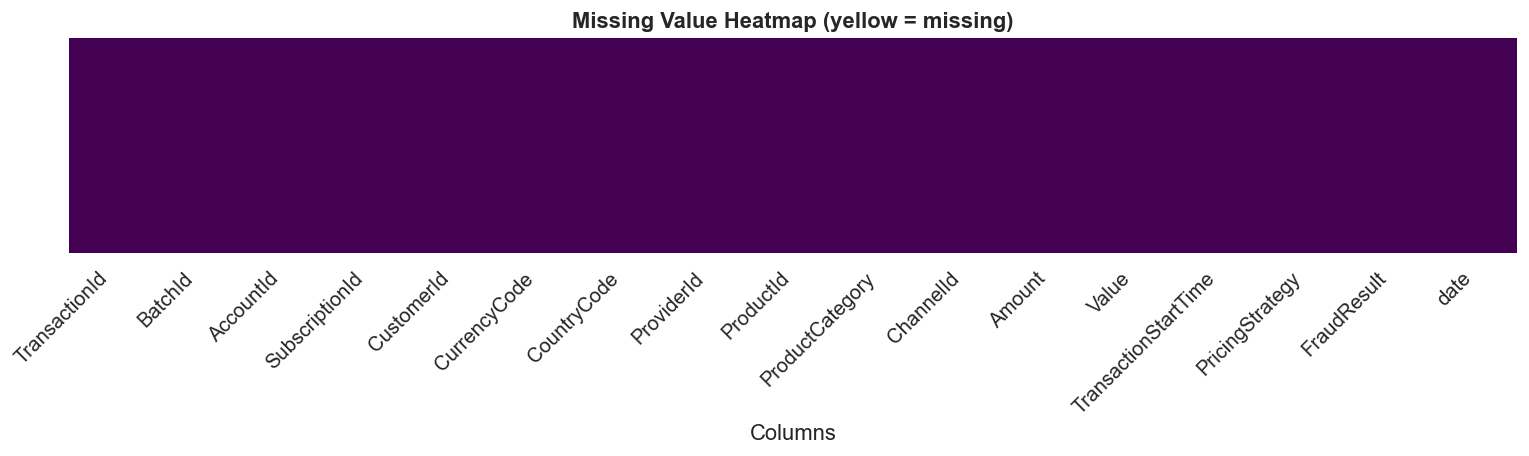

In [21]:
# Visual: missing value heatmap
fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis',
    ax=ax
)
ax.set_title('Missing Value Heatmap (yellow = missing)', fontweight='bold')
ax.set_xlabel('Columns')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
# Check for duplicates
dup_count = df.duplicated().sum()
dup_tx    = df['TransactionId'].duplicated().sum()
print(f'Fully duplicate rows    : {dup_count:,}')
print(f'Duplicate TransactionIds: {dup_tx:,}')

Fully duplicate rows    : 0
Duplicate TransactionIds: 0


---
## 7. Outlier Detection

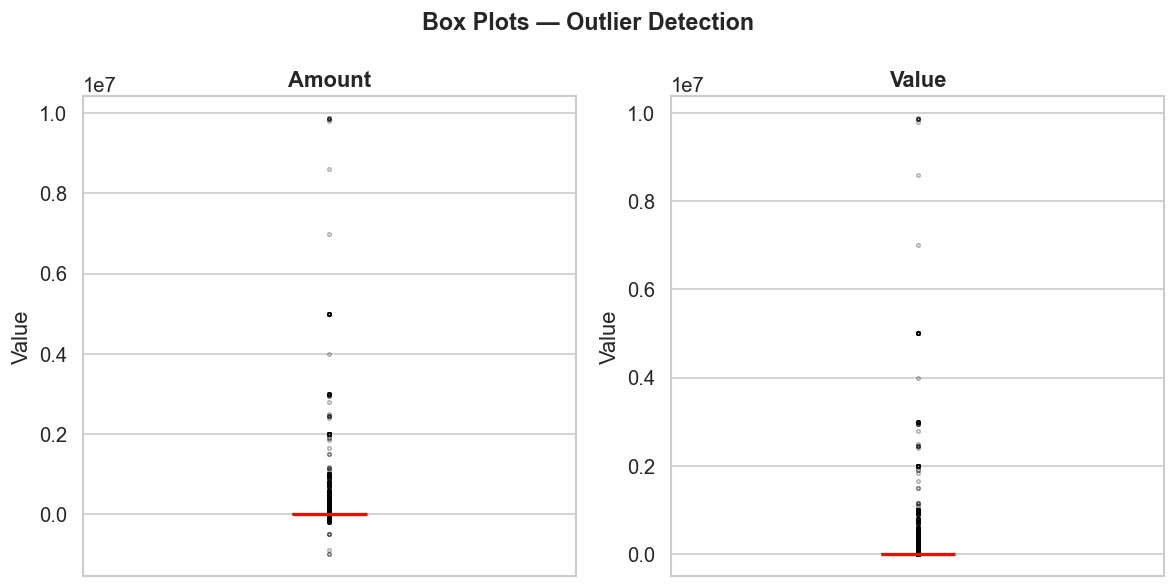

In [23]:
# Box plots for numerical features
box_cols = [c for c in num_cols if c not in ['FraudResult', 'CountryCode', 'PricingStrategy']]

fig, axes = plt.subplots(1, len(box_cols), figsize=(5 * len(box_cols), 5))
if len(box_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, box_cols):
    ax.boxplot(
        df[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.6),
        medianprops=dict(color='red', linewidth=2),
        flierprops=dict(marker='o', markersize=2, alpha=0.3, color='grey')
    )
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Value')
    ax.set_xticks([])

plt.suptitle('Box Plots — Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
# IQR-based outlier count per column
print('IQR-BASED OUTLIER COUNTS')
print(f'  {"Column":<25} {"Outliers":>10} {"% of total":>12}')
print('  ' + '-' * 50)
for col in box_cols:
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    pct = outliers / len(df) * 100
    print(f'  {col:<25} {outliers:>10,} {pct:>11.2f}%')

IQR-BASED OUTLIER COUNTS
  Column                      Outliers   % of total
  --------------------------------------------------
  Amount                        24,441       25.55%
  Value                          9,021        9.43%


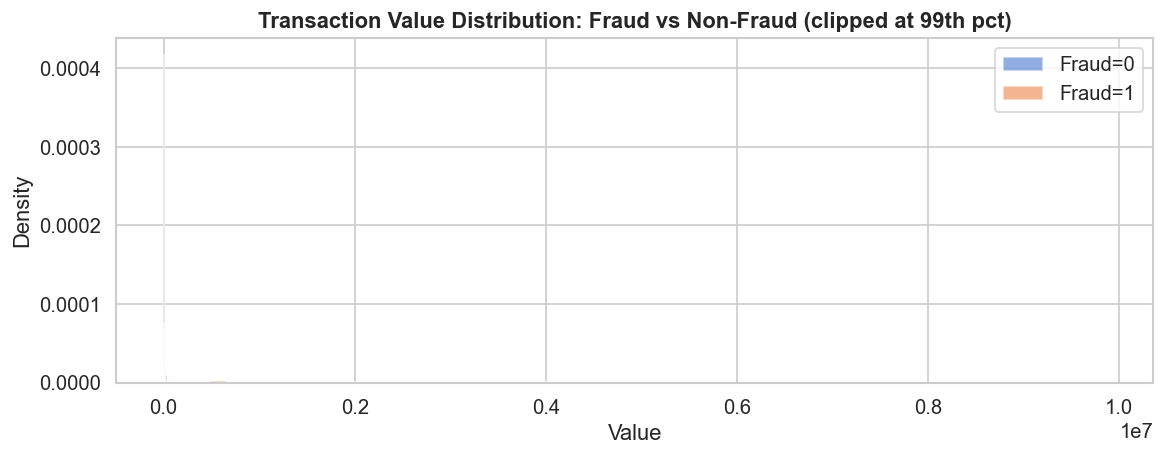

In [25]:
# Fraud vs non-fraud amount distribution
fig, ax = plt.subplots(figsize=(10, 4))

for label, grp in df.groupby('FraudResult'):
    ax.hist(
        grp['Value'].clip(upper=grp['Value'].quantile(0.99)),
        bins=60,
        alpha=0.6,
        label=f'Fraud={int(label)}',
        density=True
    )

ax.set_title('Transaction Value Distribution: Fraud vs Non-Fraud (clipped at 99th pct)', fontweight='bold')
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. RFM Foundation — Customer-Level Aggregation

Since Task 4 requires building RFM features for clustering, we preview the customer-level patterns here.

In [26]:
snapshot_date = df['TransactionStartTime'].max()

rfm = df.groupby('CustomerId').agg(
    recency   =('TransactionStartTime', lambda x: (snapshot_date - x.max()).days),
    frequency =('TransactionId', 'count'),
    monetary  =('Amount', 'sum')
).reset_index()

print(f'Unique customers: {len(rfm):,}')
rfm.describe().round(2)

Unique customers: 3,742


,recency,frequency,monetary
count,3742.00,3742.00,3.742000e+03
mean,30.46,25.56,1.717377e+05
std,27.12,96.93,2.717305e+06
min,0.00,1.00,-1.049000e+08
25%,5.00,2.00,4.077440e+03
50%,24.00,7.00,2.000000e+04
75%,53.00,20.00,7.996775e+04
max,90.00,4091.00,8.345124e+07


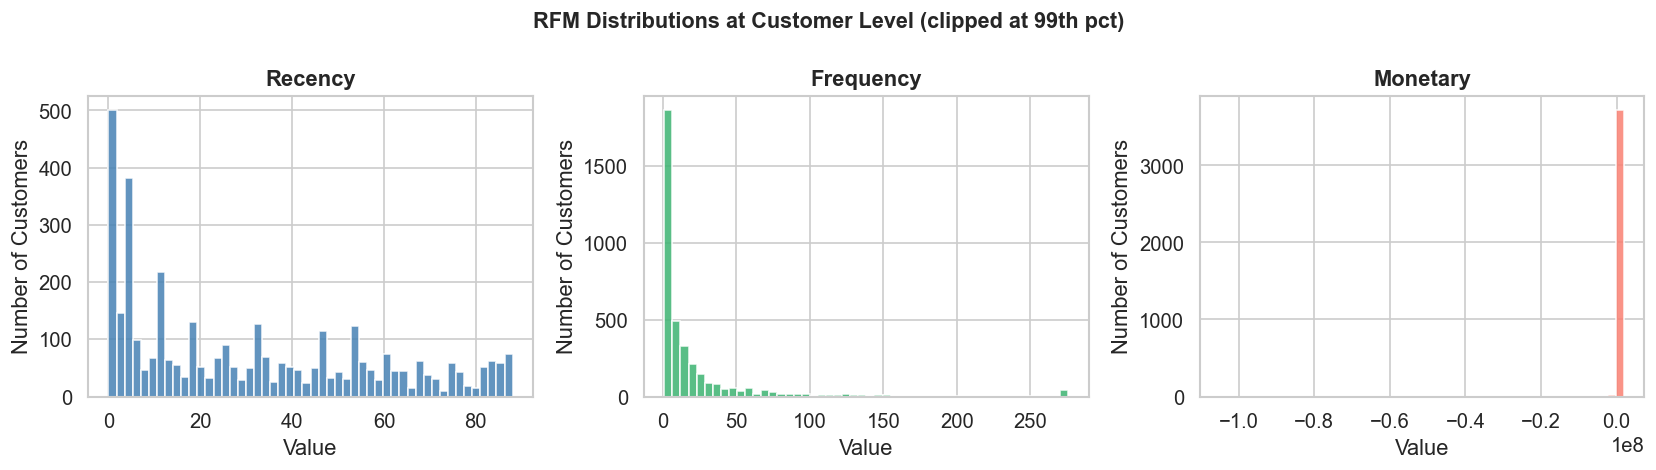

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, color in zip(axes,
                          ['recency', 'frequency', 'monetary'],
                          ['steelblue', 'mediumseagreen', 'salmon']):
    data = rfm[col].clip(upper=rfm[col].quantile(0.99))
    ax.hist(data, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col.capitalize(), fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Number of Customers')

plt.suptitle('RFM Distributions at Customer Level (clipped at 99th pct)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Key Insights Summary

---

### Insight 1 — Severe Class Imbalance in the Fraud Label

The `FraudResult` column is extremely imbalanced: only **193 out of 95,662 transactions
are fraudulent — a fraud rate of just 0.20%**. This means the dataset has a 495:1
non-fraud to fraud ratio. Any model trained directly on this label without correction
(e.g., SMOTE, class weighting, threshold tuning) will be biased toward predicting the
majority class and achieve misleadingly high accuracy while missing almost all fraud cases.
This also confirms that `FraudResult` alone cannot serve as a reliable proxy for credit
default — it captures payment fraud, not repayment risk.

---

### Insight 2 — Amount is Highly Skewed with a Large Share of Negative Values

`Amount` ranges from **−1,000,000 to +9,880,000**, with **38,189 negative values (40% of
rows)** representing credits back to the customer. The distribution is extremely
right-skewed (mean of 6,718 vs. median of 1,000), with **25.55% of Amount values flagged
as outliers by the IQR method**. Raw `Amount` cannot be fed directly into distance-based
or linear models without log-transformation or clipping. `Value` (the absolute amount) is
cleaner but still skewed, with 9.43% outliers. Since `Amount` and `Value` are 98.97%
correlated, only one should be retained as a feature — `Value` is preferred as it avoids
the sign ambiguity.

---

### Insight 3 — Transaction Activity is Concentrated in a 90-Day Window

The dataset spans exactly **90 days: 15 November 2018 to 13 February 2019**. Daily volume
shows temporal spikes likely reflecting promotions or end-of-month payment cycles. This
short window has a critical implication for RFM: with only 90 days of history, **Recency
values range from 0 to 90 days** and the snapshot date must be set to the dataset maximum
(`2019-02-13`) to ensure consistency. Customers with recency near 90 have been inactive
for the entire observation window — a strong disengagement signal for the high-risk proxy.

---

### Insight 4 — CountryCode is Constant; Amount and Value are Near-Perfectly Collinear

`CountryCode` has a **single unique value (256) across all 95,662 rows** — it provides
zero predictive signal and must be dropped during feature engineering. Additionally,
`Amount` and `Value` have a Pearson correlation of **0.99**, confirming near-perfect
collinearity. Retaining both would introduce multicollinearity in linear models and add
noise in tree-based models. `Value` will be kept; `Amount` will be used only for
deriving the sign (debit vs. credit) as a separate binary feature.

---

### Insight 5 — Customer Behavior is Highly Heterogeneous at the RFM Level

The dataset contains **3,742 unique customers** averaging 25.6 transactions each, but
the distribution is heavily skewed: the median customer has only **7 transactions** while
the most active customer has **4,091**. Monetary value is similarly heterogeneous —
the median customer total is **20,000 UGX** while the maximum reaches **83.5 million**.
Recency ranges from 0 to 90 days with a mean of 30 days. This three-way heterogeneity
(low-frequency + low-monetary + high-recency customers vs. the opposite) is exactly the
signal K-Means clustering will exploit in Task 4 to define the high-risk proxy group.

---

### Feature Engineering Hypotheses (carried into Task 3)

1. Drop `CountryCode` (zero variance) and `Amount` — keep `Value` and add a binary
   `is_debit` flag derived from the sign of `Amount`.
2. Log-transform `Value` to reduce extreme right-skew before modeling.
3. Extract `hour`, `day_of_week`, `month` from `TransactionStartTime` — the 90-day
   window with temporal spikes suggests time-of-day and day-of-week correlate with risk.
4. Create customer-level RFM aggregates: total `Value`, transaction count, std of
   `Value`, recency in days — these become the clustering features in Task 4.
5. WoE-encode `ProductCategory`, `ChannelId`, and `ProviderId` against the proxy target —
   `financial_services` and `airtime` dominate (95% of transactions) and may show
   distinct risk profiles worth capturing.